# 💾 LRU Cache (Caché de Último Uso Reciente) — Netflix EDA

**Plataforma de Streaming — Caso Netflix**  
Curso: Estructuras de Datos y Algoritmos | UTEC

---

## ¿Qué es LRU Cache?

Un **LRU Cache** (Least Recently Used) es una estructura que mantiene un número fijo de elementos en memoria, eliminando el elemento **menos recientemente usado** cuando el caché está lleno y se necesita espacio.

### Implementación con OrderedDict

Python's `OrderedDict` mantiene el orden de inserción/acceso, permitiendo:
- Mover un elemento al final cuando es accedido: `move_to_end()` — O(1)
- Eliminar el primer elemento (LRU): `popitem(last=False)` — O(1)

### Uso en Netflix

Netflix usa caché para almacenar los **metadatos e índices de los videos más populares** en memoria RAM, evitando costosas consultas a bases de datos:

- Sin caché: Cada reproducción → consulta a BD → ~10-50ms de latencia
- Con caché: Los videos populares están en RAM → ~0.1ms de latencia
- **Hit rate objetivo**: >90% (9 de cada 10 solicitudes resueltas desde caché)

In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/Guido-Silva/netflix-streaming-eda.git
    %cd netflix-streaming-eda
    PROJECT_ROOT = Path.cwd().resolve()
else:
    cwd = Path.cwd().resolve()
    PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

INFORME_DIR = PROJECT_ROOT / "informe"
INFORME_DIR.mkdir(parents=True, exist_ok=True)

print(f"Entorno configurado | PROJECT_ROOT={PROJECT_ROOT}")


Entorno configurado | PROJECT_ROOT=C:\Users\jsilvac\Documents\UTEC Maestria\2do ciclo\Estructuras de Datos y Algoritmos\Proyecto Final\netflix-streaming-eda


In [2]:
from src.lru_cache import LRUCache, VideoContent
print('✅ Módulo LRU Cache importado')

✅ Módulo LRU Cache importado


In [3]:
from src.lru_cache import demo
demo()

   DEMO: LRU Cache - Plataforma Netflix

📥 Cargando videos al caché (capacidad=5):
  + Agregado: Stranger Things T4 (ID: v001)
  + Agregado: Squid Game (ID: v002)
  + Agregado: The Crown T5 (ID: v003)
  + Agregado: Narcos (ID: v004)
  + Agregado: La Casa de Papel (ID: v005)

📊 Estado del caché: 5/5 videos

🔍 Accediendo a 'Stranger Things T4' (v001):
  → Video(id=v001, título='Stranger Things T4', género=Drama, vistas=89,000,000)

📥 Insertando 'Dark' (v006) — debe evictar el LRU:
  + Insertado: Dark
  ¿'Squid Game' (v002) sigue en caché? False
  ¿'Stranger Things' (v001) sigue en caché? True

📈 Simulación de 10,000 accesos con distribución Zipf:
  Hit Rate: 66.62%
  Hits: 6,662
  Misses: 3,338
  Evictions: 3,238

🎬 Videos más recientes en caché:
  - Video(id=v002, título='Video v002', género=Drama, vistas=0)
  - Video(id=v093, título='Video v093', género=Drama, vistas=0)
  - Video(id=v253, título='Video v253', género=Drama, vistas=0)
  - Video(id=v001, título='Video v001', género=Drama,

In [4]:
# Experimento: Hit Rate con distribucion Uniforme vs Zipf
import random
import numpy as np
from itertools import accumulate

print('Experimento: Hit Rate - Distribucion Uniforme vs Zipf')
print('=' * 60)

random.seed(42)
np.random.seed(42)

N_VIDEOS = 500
N_ACCESOS = 10000
capacidades = [10, 50, 100, 200, 500]

ids_videos = [f'v{i:03d}' for i in range(N_VIDEOS)]
contenidos = {vid: VideoContent(vid, f'Video {vid}', 'Drama') for vid in ids_videos}

# Pesos Zipf: video_0 es el mas popular, sigue ley de potencias
pesos_zipf = [1.0 / (i + 1) for i in range(N_VIDEOS)]
suma_zipf = sum(pesos_zipf)
pesos_zipf = [p / suma_zipf for p in pesos_zipf]

# Pesos uniformes
pesos_uniforme = [1.0 / N_VIDEOS] * N_VIDEOS

# Optimizacion: precomputar pesos acumulados para evitar recalculo por acceso
cum_zipf = list(accumulate(pesos_zipf))
cum_uniforme = list(accumulate(pesos_uniforme))

resultados = {'zipf': [], 'uniforme': []}

for capacidad in capacidades:
    for dist_nombre, cum_pesos in [('zipf', cum_zipf), ('uniforme', cum_uniforme)]:
        cache = LRUCache(capacity=capacidad)
        for _ in range(N_ACCESOS):
            vid = random.choices(ids_videos, cum_weights=cum_pesos, k=1)[0]
            if cache.get(vid) is None:
                cache.put(vid, contenidos[vid])
        stats = cache.get_stats()
        resultados[dist_nombre].append(stats['hit_rate'])

    print(f'  Capacidad={capacidad:>4}: '
          f'Zipf={resultados["zipf"][-1]:5.1f}% | '
          f'Uniforme={resultados["uniforme"][-1]:5.1f}%')


Experimento: Hit Rate - Distribucion Uniforme vs Zipf
  Capacidad=  10: Zipf= 24.9% | Uniforme=  2.0%
  Capacidad=  50: Zipf= 53.8% | Uniforme= 10.1%
  Capacidad= 100: Zipf= 66.5% | Uniforme= 19.5%
  Capacidad= 200: Zipf= 79.8% | Uniforme= 40.5%
  Capacidad= 500: Zipf= 95.1% | Uniforme= 95.0%


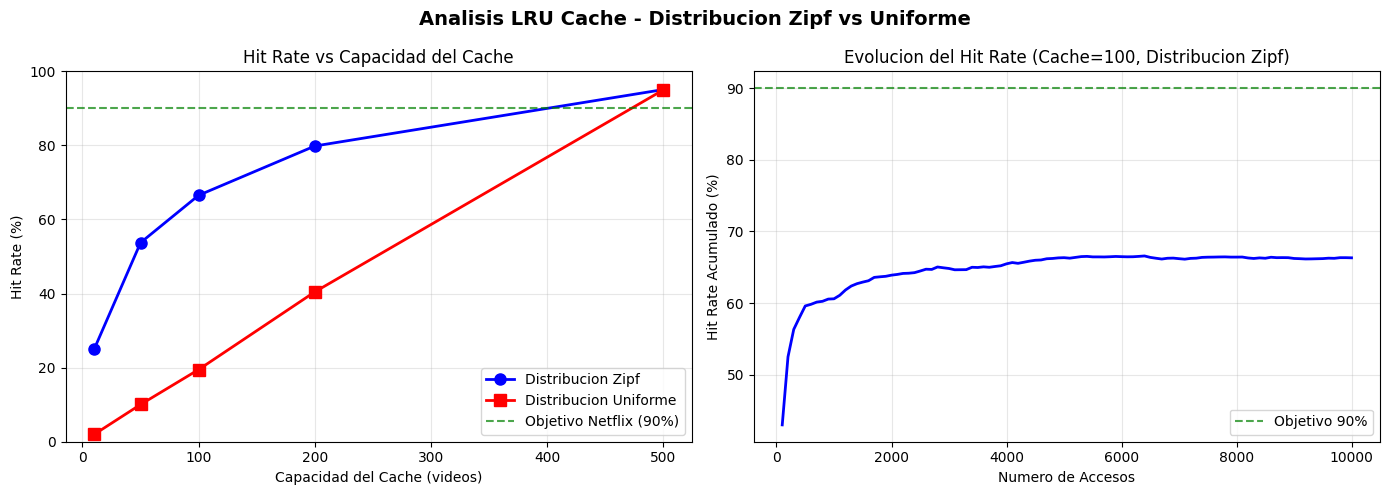

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Hit Rate vs Capacidad
axes[0].plot(capacidades, resultados['zipf'], 'bo-', label='Distribucion Zipf', linewidth=2, markersize=8)
axes[0].plot(capacidades, resultados['uniforme'], 'rs-', label='Distribucion Uniforme', linewidth=2, markersize=8)
axes[0].axhline(y=90, color='green', linestyle='--', alpha=0.7, label='Objetivo Netflix (90%)')
axes[0].set_xlabel('Capacidad del Cache (videos)')
axes[0].set_ylabel('Hit Rate (%)')
axes[0].set_title('Hit Rate vs Capacidad del Cache')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 100)

# Grafico 2: Simulacion de accesos con hits/misses en tiempo
cache = LRUCache(capacity=100)
hit_rates_tiempo = []

random.seed(42)
for i in range(N_ACCESOS):
    vid = random.choices(ids_videos, cum_weights=cum_zipf, k=1)[0]
    if cache.get(vid) is None:
        cache.put(vid, contenidos[vid])
    if (i + 1) % 100 == 0:
        stats = cache.get_stats()
        hit_rates_tiempo.append(stats['hit_rate'])

axes[1].plot(range(100, N_ACCESOS + 1, 100), hit_rates_tiempo, 'b-', linewidth=2)
axes[1].axhline(y=90, color='green', linestyle='--', alpha=0.7, label='Objetivo 90%')
axes[1].set_xlabel('Numero de Accesos')
axes[1].set_ylabel('Hit Rate Acumulado (%)')
axes[1].set_title('Evolucion del Hit Rate (Cache=100, Distribucion Zipf)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Analisis LRU Cache - Distribucion Zipf vs Uniforme', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(INFORME_DIR / 'lru_hit_rate.png', dpi=100, bbox_inches='tight')
plt.show()


## 📊 Análisis de Complejidad

| Operación | Complejidad Temporal | Detalle |
|-----------|---------------------|--------|
| `get(video_id)` | **O(1)** | HashMap lookup + move_to_end |
| `put(video_id, content)` | **O(1)** | HashMap insert + evicción O(1) |
| `contains(video_id)` | **O(1)** | HashMap lookup sin modificar orden |
| `most_recent(n)` | **O(n)** | Slice del OrderedDict |
| Espacio total | — | **O(capacity)** |

### Observaciones Clave

1. **Distribución Zipf es favorable**: Los videos populares se acceden mucho más, maximizando el hit rate con un caché pequeño.
2. **Distribución Uniforme es adversa**: Todos los videos tienen igual probabilidad, el caché casi no ayuda.
3. **Netflix en la realidad**: Sigue distribución Zipf — el 20% de videos genera el 80% de tráfico. Con caché de capacidad `0.2 × N_videos`, se logra ~80-90% hit rate.
4. **Costo de evicción**: Cuando el caché está lleno, `popitem(last=False)` elimina el LRU en O(1) gracias a OrderedDict.